In [14]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jaxopt
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tinygp import GaussianProcess, kernels, transforms
from tinygp.kernels.distance import L2Distance
from tqdm.auto import tqdm

In [ ]:
NUM_TRAIN_SAMPLES = 1000
NUM_TEST_SAMPLES = 200

ell = np.arange(2, 3001)
dl_to_cl_factor = ell * (ell + 1) / (2 * np.pi)

DATA_DIR = "./hackathon_cmb_emulator/data"


def load_spectra(data_dir, n):
    # cl_<i>.txt has TT, TE, EE columns; we only need EE.
    cls = np.zeros((n, len(ell)))
    for i in range(1, n + 1):
        cl_tt, cl_te, cl_ee = np.loadtxt(f"{data_dir}/cl_{i}.txt", unpack=True)  # noqa: RUF059
        cls[i - 1] = cl_ee
    return cls


train_cosmologies = np.loadtxt(f"{DATA_DIR}/train_1000_wide/cosmologies.txt")
test_cosmologies = np.loadtxt(f"{DATA_DIR}/test_200/cosmologies.txt")
train_cls = load_spectra(f"{DATA_DIR}/train_1000_wide", NUM_TRAIN_SAMPLES)
test_cls = load_spectra(f"{DATA_DIR}/test_200", NUM_TEST_SAMPLES)

In [16]:
train_logcls = np.log(train_cls / dl_to_cl_factor)

cls_scaler = StandardScaler().fit(train_logcls)
train_logcls = cls_scaler.transform(train_logcls)

In [17]:
N_COMPONENTS = 60

pca = PCA(n_components=N_COMPONENTS, svd_solver="randomized", iterated_power=3, random_state=42)
train_pca_coeffs = pca.fit_transform(train_logcls)  # (n_samples, N_COMPONENTS)

print("train_pca_coeffs shape:", train_pca_coeffs.shape)
print("per-component std (what each GP has to fit):")
print(np.round(train_pca_coeffs.std(axis=0), 3))

train_pca_coeffs shape: (1000, 60)
per-component std (what each GP has to fit):
[4.8544e+01 1.8434e+01 1.1483e+01 9.6580e+00 5.3190e+00 4.5490e+00
 3.4790e+00 2.9850e+00 1.3880e+00 1.3120e+00 1.1290e+00 9.3700e-01
 6.6800e-01 4.9300e-01 4.3900e-01 4.1700e-01 3.6600e-01 3.4800e-01
 2.8800e-01 2.4800e-01 2.2400e-01 1.9100e-01 1.8300e-01 1.8000e-01
 1.6900e-01 1.2900e-01 1.1000e-01 1.0500e-01 9.6000e-02 9.1000e-02
 8.5000e-02 7.7000e-02 6.8000e-02 6.3000e-02 5.6000e-02 5.2000e-02
 4.8000e-02 4.5000e-02 4.3000e-02 3.6000e-02 3.2000e-02 2.9000e-02
 2.6000e-02 2.6000e-02 2.4000e-02 2.3000e-02 2.1000e-02 2.1000e-02
 1.9000e-02 1.8000e-02 1.8000e-02 1.7000e-02 1.6000e-02 1.6000e-02
 1.5000e-02 1.5000e-02 1.3000e-02 1.3000e-02 1.2000e-02 1.2000e-02]


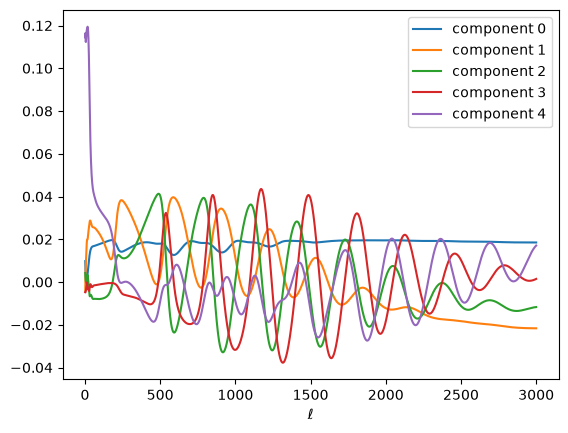

In [18]:
# Sanity check: what do the leading PCA modes look like?
for i in range(5):
    plt.plot(ell, pca.components_[i], label=f"component {i}")
plt.xlabel(r"$\ell$")
plt.legend()
plt.show()

In [19]:
coeff_scaler = StandardScaler().fit(train_pca_coeffs)
Y_train = coeff_scaler.transform(train_pca_coeffs)

cosmo_scaler = StandardScaler().fit(train_cosmologies)
X_train = jnp.asarray(cosmo_scaler.transform(train_cosmologies))

In [20]:
N_IN = train_cosmologies.shape[1]
N_RESTARTS = 2

# L2Distance makes this match sklearn's Matern (tinygp's default is L1/Manhattan, a different kernel).
KERNEL_FAMILY = lambda: kernels.Matern52(distance=L2Distance())

DIAG = 1e-6  # fixed numerical jitter, not fitted


def build_gp(theta, X_):
    amp = jnp.exp(theta["log_amp"])
    lengthscale = jnp.exp(theta["log_ell"])  # one per input dimension
    kernel = amp**2 * transforms.Linear(1.0 / lengthscale, KERNEL_FAMILY())  # amp**2 = kernel variance
    return GaussianProcess(kernel, X_, diag=DIAG)


def neg_log_prob(theta, X_, y_):
    return -build_gp(theta, X_).log_probability(y_)

In [21]:
# scipy's compiled L-BFGS-B (via jaxopt), matching sklearn's GP optimizer. Can't run
# inside jit/pmap since it shells out to scipy, so components are fit one at a time below.
ELL_BOUNDS = (1e-2, 1e3)
VARIANCE_BOUNDS = (1e-3, 1e3)  # = amp**2 bounds
LOWER = {"log_amp": 0.5 * np.log(VARIANCE_BOUNDS[0]), "log_ell": jnp.full(N_IN, np.log(ELL_BOUNDS[0]))}
UPPER = {"log_amp": 0.5 * np.log(VARIANCE_BOUNDS[1]), "log_ell": jnp.full(N_IN, np.log(ELL_BOUNDS[1]))}
scipy_solver = jaxopt.ScipyBoundedMinimize(fun=neg_log_prob, method="L-BFGS-B")


def fit_one_output(X_, y_, n_restarts=N_RESTARTS, seed=0):
    """Fit one GP with multi-start restarts (the likelihood isn't convex).
    Restarts are seeded from a narrow window -- a wide random draw can send several
    lengthscales to their bound at once, which collapses the kernel to near rank-1 and
    blows up the likelihood. The optimizer can still reach the full wide bounds from a
    narrow start when the data supports it.
    Returns every restart's final NLL too, to check if restarts land on different minima."""
    rng_r = np.random.default_rng(seed)
    best = None
    restart_vals = []
    for _ in range(n_restarts):
        theta0 = {
            "log_amp": jnp.asarray(rng_r.uniform(-1, 1)),
            "log_ell": jnp.asarray(rng_r.uniform(-1, 1, N_IN)),
        }
        soln = scipy_solver.run(theta0, bounds=(LOWER, UPPER), X_=X_, y_=y_)
        restart_vals.append(float(soln.state.fun_val))
        if best is None or soln.state.fun_val < best.state.fun_val:
            best = soln
    return best.params, np.array(restart_vals)

In [22]:
all_restart_vals = []
fitted_params = []
for k in tqdm(range(N_COMPONENTS), desc="fitting GPs"):
    params, restart_vals = fit_one_output(X_train, Y_train[:, k], seed=k)
    all_restart_vals.append(restart_vals)
    fitted_params.append(params)

fitting GPs: 100%|██████████| 60/60 [17:58<00:00, 17.97s/it]


In [23]:
for k, params in enumerate(fitted_params):
    amp = float(jnp.exp(params["log_amp"]))
    lengthscale = np.exp(np.asarray(params["log_ell"]))
    restart_nlls = all_restart_vals[k]
    spread = restart_nlls.max() - restart_nlls.min()
    print(f"component {k:2d}: amp={amp:8.4f}  ell={np.round(lengthscale, 3)}  "
          f"restart_nlls={np.round(restart_nlls, 4)}  spread={spread:.4f}")

component  0: amp= 31.6228  ell=[169.028  33.119  33.466 114.078 515.156 544.069]  restart_nlls=[-4992.9401 -4992.9401]  spread=0.0000
component  1: amp= 31.6228  ell=[ 68.662  18.345  31.918  71.347 601.62  310.25 ]  restart_nlls=[-4299.4871 -4299.4871]  spread=0.0000
component  2: amp= 31.6228  ell=[ 33.731   8.218  27.639  65.31  364.926 409.448]  restart_nlls=[-3331.5802 -3331.5802]  spread=0.0000
component  3: amp= 10.9673  ell=[  18.169    4.223   18.077   36.034  185.689 1000.   ]  restart_nlls=[-3059.4921 -3059.4921]  spread=0.0000
component  4: amp= 31.6228  ell=[ 21.006   5.369  25.799  46.829 252.53   55.598]  restart_nlls=[-2206.1818 -2206.1818]  spread=0.0000
component  5: amp= 31.6228  ell=[ 17.408   4.441  20.518  41.958 254.176  60.369]  restart_nlls=[-1850.7215  1418.9385]  spread=3269.6600
component  6: amp= 31.6228  ell=[ 32.694   7.838  23.145  59.436 311.422  43.575]  restart_nlls=[-2618.0012 -2618.0012]  spread=0.0000
component  7: amp= 31.6228  ell=[ 13.472   3.5

In [24]:
# Predict each PCA coefficient for the test cosmologies, then invert
# PCA -> component scaling -> log(Cl) scaling -> Cl to get predicted spectra.
X_test = jnp.asarray(cosmo_scaler.transform(test_cosmologies))

pred_coeffs_scaled = jnp.stack(
    [build_gp(params, X_train).predict(Y_train[:, k], X_test) for k, params in enumerate(fitted_params)],
    axis=1,
)  # (NUM_TEST_SAMPLES, N_COMPONENTS)

pred_coeffs = coeff_scaler.inverse_transform(np.asarray(pred_coeffs_scaled))
pred_logcls_scaled = pca.inverse_transform(pred_coeffs)
pred_logcls = cls_scaler.inverse_transform(pred_logcls_scaled)
pred_cls = np.exp(pred_logcls) * dl_to_cl_factor

# Full-sky, noise-free cosmic variance for an auto-spectrum (Knox 1995):
# sigma(ell) = sqrt(2 / (2*ell+1)) * Cl(ell). Errors in units of this tell you whether
# the emulator is accurate compared to the irreducible sample variance of the sky itself.
cosmic_variance = np.sqrt(2 / (2 * ell + 1)) * test_cls
err_sigma = (pred_cls - test_cls) / cosmic_variance

print("mean |error| in cosmic-variance sigma per spectrum:", np.mean(np.abs(err_sigma), axis=1).mean())
print("median |error| in cosmic-variance sigma per spectrum:", np.median(np.mean(np.abs(err_sigma), axis=1)))
print("worst-case |error| in cosmic-variance sigma:", np.abs(err_sigma).max())

mean |error| in cosmic-variance sigma per spectrum: 0.0944492164420425
median |error| in cosmic-variance sigma per spectrum: 0.07376055921222971
worst-case |error| in cosmic-variance sigma: 4.798742926387678


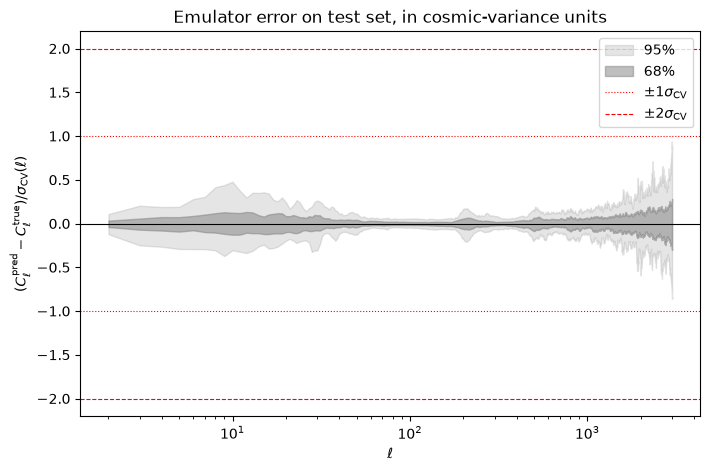

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

lo95, hi95 = np.percentile(err_sigma, [2.5, 97.5], axis=0)
lo68, hi68 = np.percentile(err_sigma, [16, 84], axis=0)
ax.fill_between(ell, lo95, hi95, alpha=0.2, color="gray", label="95%")
ax.fill_between(ell, lo68, hi68, alpha=0.5, color="gray", label="68%")
ax.axhline(0, color="black", lw=0.8)
ax.axhline(1, color="red", lw=0.8, ls=":", label=r"$\pm 1\sigma_{\rm CV}$")
ax.axhline(-1, color="red", lw=0.8, ls=":")
ax.axhline(2, color="red", lw=0.8, ls="--", label=r"$\pm 2\sigma_{\rm CV}$")
ax.axhline(-2, color="red", lw=0.8, ls="--")

ax.set_xscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$(C_\ell^{\rm pred} - C_\ell^{\rm true}) / \sigma_{\rm CV}(\ell)$")
ax.set_title("Emulator error on test set, in cosmic-variance units")
ax.legend()
plt.show()

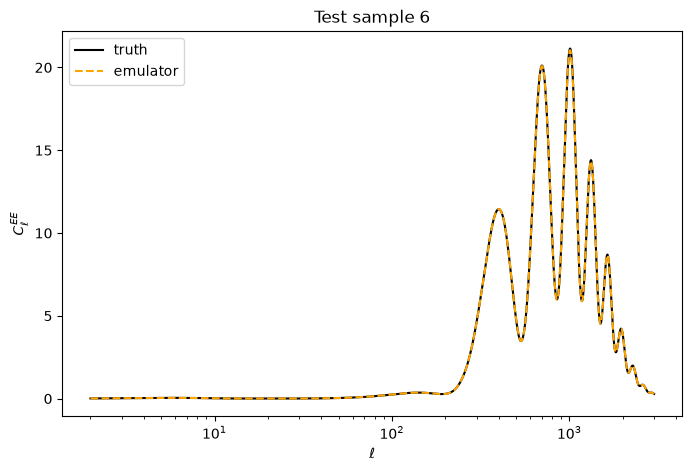

In [26]:
i = 6
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ell, test_cls[i], color="black", label="truth")
ax.plot(ell, pred_cls[i], color="orange", ls="--", label="emulator")

ax.set_xscale("log")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$C_\ell^{EE}$")
ax.set_title(f"Test sample {i}")
ax.legend()
plt.show()